# Bias in supervised ML: the COMPAS case study

**CS212 — Introduction to Data Science and Machine Learning**

The file `compas-scores-two-years.csv` contains **N ≈ 7,214 defendants** from
**Broward County, Florida**, arrested between 2013 and 2014. For each
defendant we have:

- **Demographics:** `sex`, `race`, `age`, `age_cat`.
- **Criminal history:** `priors_count`, `c_charge_degree` (felony / misdemeanor),
  `c_charge_desc`.
- **COMPAS output:** `decile_score` (1–10), `score_text` (Low / Medium / High).
- **Outcome:** `two_year_recid` (was the defendant re-arrested within two
  years?), `is_recid`.

A central subtlety: **the label `two_year_recid` is not "did this person
commit a new crime within two years". It is "was this person *arrested* for a
new offence within two years".** The gap between those two definitions is a
main source of *measurement bias* in this dataset — and, by extension, in every
analysis built on top of it. We return to this at the end of the notebook.
 
**Learning objectives**

By the end of this notebook you should be able to:

1. Identify three distinct sources of bias in a supervised ML pipeline (label,
   feature, evaluation) and connect them to the taxonomy of
   **Barocas, Hardt & Narayanan (2023)**.
2. Compute — by hand and with **Fairlearn** — the three canonical group
   fairness metrics on a two-group problem: **demographic parity gap**,
   **equalised odds gap**, and **calibration / predictive parity by group**.
3. Demonstrate empirically the **Kleinberg–Mullainathan–Raghavan (2016)**
   impossibility theorem on real data.
4. Apply a post-processing mitigation (`ThresholdOptimizer`) and quantify the
   accuracy–fairness trade-off it induces.


In [1]:
# %pip install fairlearn

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             roc_auc_score, brier_score_loss)

from fairlearn.metrics import (MetricFrame, demographic_parity_difference,
        equalized_odds_difference,selection_rate,
        true_positive_rate,false_positive_rate)
from fairlearn.postprocessing import ThresholdOptimizer

sns.set_theme(context="notebook", style="whitegrid")

RNG = np.random.RandomState(212)
random.seed(234)

## Import data

In [3]:
COMPAS_URL = (
    "https://raw.githubusercontent.com/propublica/"
    "compas-analysis/master/compas-scores-two-years.csv"
)

raw = pd.read_csv(COMPAS_URL)

print(f"raw shape: {raw.shape}")
raw.head(3)


raw shape: (7214, 53)


,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1


### 2.1 Race composition in the raw file

In [4]:
race_counts = (
    raw["race"].value_counts()
       .rename_axis("race")
       .to_frame("n")
       .assign(pct=lambda d: 100 * d["n"] / d["n"].sum())
       .round({"pct": 2})
)
race_counts


,n,pct
race,,
African-American,3696,51.23
Caucasian,2454,34.02
Hispanic,637,8.83
Other,377,5.23
Asian,32,0.44
Native American,18,0.25


The table above confirms the numerical justification for restricting the analysis to the two largest groups: every other subgroup has either too few observations (Asian, Native American) or a substantial fraction of ambiguous/mixed self-identifications (`Other`, `Hispanic` as cross-cutting with race) to admit a clean two-way comparison.

## 3. Applying the ProPublica filter and restricting to two groups

The ProPublica team published a documented filter over the raw file that
removes records with:

- inconsistent screening dates (`days_b_screening_arrest` outside ±30 days);
- missing outcome labels (`is_recid == -1`);
- charge degree `"O"` (ordinary traffic);
- missing score (`score_text == "N/A"`).

Applying the **same** filter is how we make our numbers comparable to the
published literature.

In [5]:
df = (
    raw[(raw["days_b_screening_arrest"] <= 30)
      & (raw["days_b_screening_arrest"] >= -30)
      & (raw["is_recid"] != -1)
      & (raw["c_charge_degree"] != "O")
      & (raw["score_text"] != "N/A")]
    .copy()
)

# Restrict to the two largest groups.
df = df[df["race"].isin(["African-American", "Caucasian"])].copy()
df["race"] = pd.Categorical(df["race"],
                            categories=["Caucasian", "African-American"])

print(f"filtered shape: {df.shape}")
df["race"].value_counts()


filtered shape: (5278, 53)


race
African-American    3175
Caucasian           2103
Name: count, dtype: int64

## 4. Exploratory analysis: what the groups look like *before* any model

In [6]:
# Base-rate of the outcome per race (this is the quantity that will make
# calibration and equalised odds mutually incompatible).
df.groupby("race", observed=True)["two_year_recid"].mean().round(3)


race
Caucasian           0.391
African-American    0.523
Name: two_year_recid, dtype: float64

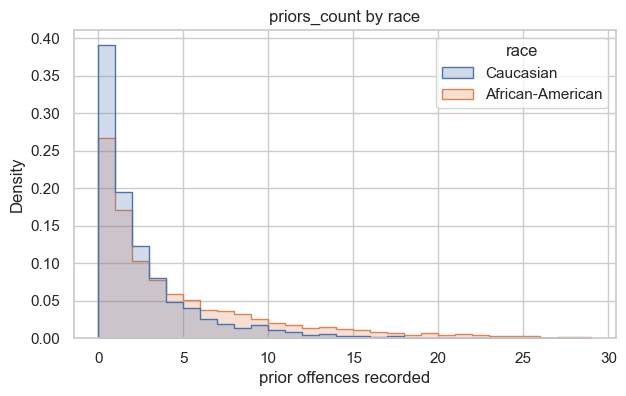

In [7]:
# Distribution of the number of prior offences per race
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df, x="priors_count", hue="race",
             stat="density", common_norm=False,
             bins=range(0, 30), element="step", ax=ax)
ax.set_title("priors_count by race")
ax.set_xlabel("prior offences recorded")
plt.show()


Two things to notice immediately.

1. The **base rate** of `two_year_recid` differs between the two groups. This is
   the single empirical fact that drives the Kleinberg impossibility we will
   meet in §8. If base rates were equal, calibration and equalised odds could
   coexist; because they aren't, they can't.
2. The feature `priors_count` — which will be one of the main predictors — has
   a very different distribution per race. Any honest conversation about
   "using priors as a feature" has to acknowledge that this feature is itself
   the output of a historical enforcement process, *not* a neutral measurement
   of criminal propensity.


## A baseline classifier

We train a very standard logistic-regression pipeline to predict `two_year_recid`. Crucially, **we do not use `race` as a feature** — this is the "fairness through unawareness" approach. Part of the point of the next section will be to show that unawareness is not enough.

In [8]:
numeric_features = ["age", "priors_count"]
categorical_features = ["sex", "c_charge_degree"]

X = df[numeric_features + categorical_features].copy()
y = df["two_year_recid"].astype(int).values
A = df["race"].values  # protected attribute, used ONLY at evaluation time

X_train, X_test, y_train, y_test, A_train, A_test = train_test_split(
    X, y, A, test_size=0.30, random_state=212, stratify=y
)

pre = ColumnTransformer(
    [("cat", OneHotEncoder(drop="first"), categorical_features)],
    remainder="passthrough",
)

clf = Pipeline([
    ("pre", pre),
    ("lr", LogisticRegression(max_iter=1000)),
])

clf.fit(X_train, y_train)
y_hat = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

print(f"overall accuracy : {accuracy_score(y_test, y_hat):.3f}")
print(f"overall AUC      : {roc_auc_score(y_test, y_prob):.3f}")
print(f"overall Brier    : {brier_score_loss(y_test, y_prob):.3f}")


overall accuracy : 0.684
overall AUC      : 0.732
overall Brier    : 0.209


## 6. Overall vs per-group performance

Accuracy looks reasonable. The whole point of this notebook is that *this single number tells you essentially nothing*. We now decompose it by race.

In [9]:
mf = MetricFrame(
    metrics={
        "accuracy": accuracy_score,
        "selection_rate": selection_rate,
        "TPR": true_positive_rate,
        "FPR": false_positive_rate,
    },
    y_true=y_test,
    y_pred=y_hat,
    sensitive_features=A_test,
)

mf.by_group.round(3)


,accuracy,selection_rate,TPR,FPR
sensitive_feature_0,,,,
African-American,0.682,0.536,0.703,0.343
Caucasian,0.686,0.248,0.412,0.151


In [10]:
# Confusion matrices by race, as rates not counts
def rate_cm(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, normalize="true")
    return pd.DataFrame(cm,
                        index=pd.Index(["y=0", "y=1"], name="true"),
                        columns=pd.Index(["ŷ=0", "ŷ=1"], name="pred")).round(3)

for g in ["Caucasian", "African-American"]:
    m = (A_test == g)
    print(f"\nConfusion matrix (rates) — {g}   n={m.sum()}")
    print(rate_cm(y_test[m], y_hat[m]))



Confusion matrix (rates) — Caucasian   n=644
pred    ŷ=0    ŷ=1
true              
y=0   0.849  0.151
y=1   0.588  0.412

Confusion matrix (rates) — African-American   n=940
pred    ŷ=0    ŷ=1
true              
y=0   0.657  0.343
y=1   0.297  0.703


Notice what happened. **Overall accuracy is similar across groups**, yet the *types* of errors the model makes are markedly different:

- For African-American defendants the **false-positive rate** (the fraction of non-recidivists the model flags as high-risk) is noticeably higher.
- For Caucasian defendants the **false-negative rate** (the fraction of actual re-offenders the model misses) is noticeably higher.

This is the empirical shape of **disparate mistreatment**. Accuracy is silent on it. Fairness metrics are designed to surface it.


## 7. The three canonical group-fairness metrics

We now compute the three metrics from the lecture slides, once by hand to make the definitions tangible, and once with Fairlearn to check that we get the same numbers.

### 7.1 Demographic parity

$$ \text{DP gap} = \bigl|\,P(\hat{Y}=1 \mid A=a) - P(\hat{Y}=1 \mid A=b)\,\bigr| $$

Equal *selection rate* across groups. Ignores the ground truth.

In [11]:
sel_by_group = pd.Series(
    {g: (y_hat[A_test == g] == 1).mean()
     for g in ["Caucasian", "African-American"]},
    name="selection_rate",
)
dp_gap = sel_by_group.max() - sel_by_group.min()

print(sel_by_group.round(3))
print(f"\ndemographic parity gap (hand)   : {dp_gap:.3f}")
print(f"demographic parity gap (Fairlearn): "
      f"{demographic_parity_difference(y_test, y_hat, sensitive_features=A_test):.3f}")


Caucasian           0.248
African-American    0.536
Name: selection_rate, dtype: float64

demographic parity gap (hand)   : 0.288
demographic parity gap (Fairlearn): 0.288


### 7.2 Equalized odds

$$ \text{TPR gap} + \text{FPR gap},\quad \text{ideally} = 0 $$

Equal true-positive *and* false-positive rates across groups. This is the metric ProPublica implicitly used.

In [17]:
def rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return dict(TPR=tp / (tp + fn), FPR=fp / (fp + tn))

per_group = {g: rates(y_test[A_test == g], y_hat[A_test == g])
             for g in ["Caucasian", "African-American"]}
per_group_df = pd.DataFrame(per_group).T.round(3)
print(per_group_df)

tpr_gap = abs(per_group["African-American"]["TPR"] - per_group["Caucasian"]["TPR"])
fpr_gap = abs(per_group["African-American"]["FPR"] - per_group["Caucasian"]["FPR"])
print(f"\nTPR gap (hand) : {tpr_gap:.3f}")
print(f"FPR gap (hand) : {fpr_gap:.3f}")
print(f"\nequalized odds diff (Fairlearn) : "
      f"{equalized_odds_difference(y_test, y_hat, sensitive_features=A_test):.3f}")


                    TPR    FPR
Caucasian         0.412  0.151
African-American  0.703  0.343

TPR gap (hand) : 0.290
FPR gap (hand) : 0.192

equalized odds diff (Fairlearn) : 0.290


### 7.3 Predictive parity / calibration by group

$$ P(Y=1 \mid \hat{Y}=1, A=a) = P(Y=1 \mid \hat{Y}=1, A=b) $$

Among those the model flags, the fraction that actually re-offend should be the same across groups. This is the metric **Northpointe** invoked in its rebuttal to ProPublica. We also plot a full calibration curve to see the shape, not just the point at threshold 0.5.

In [13]:
# PPV per group at the default 0.5 threshold
ppv = {}
for g in ["Caucasian", "African-American"]:
    m = A_test == g
    flagged = (y_hat[m] == 1)
    ppv[g] = y_test[m][flagged].mean() if flagged.sum() > 0 else np.nan

ppv_s = pd.Series(ppv, name="PPV").round(3)
print(ppv_s)
print(f"\nPPV gap (calibration gap at threshold): "
      f"{abs(ppv_s.iloc[0] - ppv_s.iloc[1]):.3f}")


Caucasian           0.619
African-American    0.704
Name: PPV, dtype: float64

PPV gap (calibration gap at threshold): 0.085


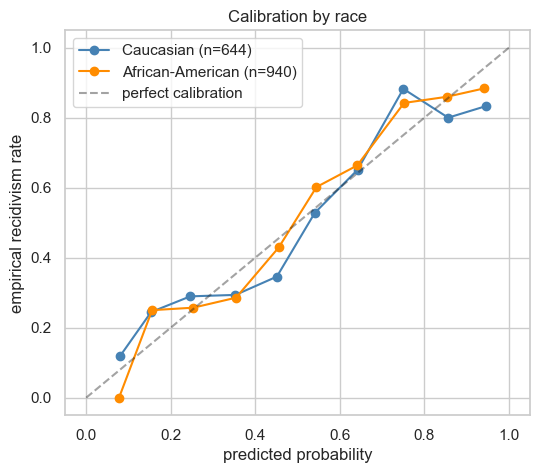

In [14]:
# Calibration curve: for each decile of the predicted probability, what is
# the observed recidivism rate in each group?
fig, ax = plt.subplots(figsize=(6, 5))
for g, c in [("Caucasian", "steelblue"), ("African-American", "darkorange")]:
    m = A_test == g
    p = y_prob[m]; y = y_test[m]
    bins = np.linspace(0, 1, 11)
    idx = np.digitize(p, bins) - 1
    idx = np.clip(idx, 0, len(bins) - 2)
    df_c = pd.DataFrame({"bin": idx, "p": p, "y": y})
    curve = df_c.groupby("bin").agg(p_mean=("p", "mean"),
                                    y_mean=("y", "mean"),
                                    n=("y", "size")).dropna()
    ax.plot(curve["p_mean"], curve["y_mean"], "o-", label=f"{g} (n={m.sum()})",
            color=c)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="perfect calibration")
ax.set_xlabel("predicted probability")
ax.set_ylabel("empirical recidivism rate")
ax.set_title("Calibration by race")
ax.legend()
plt.show()


The calibration curves sit nearly on top of each other and on the diagonal. Northpointe's claim was essentially this: *within each predicted-risk bin, the actual recidivism rate is the same for both races, so the score is fair in the sense of predictive parity*. ProPublica's claim was §7.2: *false-positive rates are very different across races, so the score is unfair in the sense of equalised odds*. Both claims are correct. The next section shows why they cannot both be "fixed" at once.

## 8. The Kleinberg–Mullainathan–Raghavan impossibility, on this data

**Theorem (Kleinberg, Mullainathan, Raghavan 2016; Chouldechova 2017).**
If the base rate of the outcome differs across groups and the classifier is not perfect, then at most *one* of the following three can hold simultaneously:

- **Calibration within groups** (equal PPV at every score level);
- **Balance for the positive class** (equal FNR across groups);
- **Balance for the negative class** (equal FPR across groups).

We check each of the three on our classifier and confirm that we can't get all three to zero. Then we sweep the decision threshold and show explicitly that **shrinking the FPR gap forces the PPV gap to grow**, and vice versa.

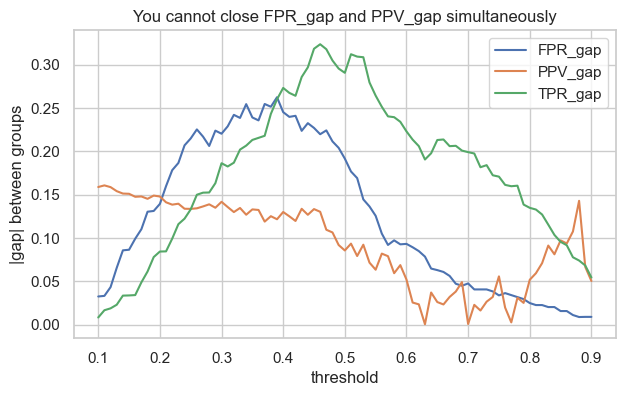

In [18]:
thresholds = np.linspace(0.1, 0.9, 81)

def gaps_at(t):
    yhat_t = (y_prob >= t).astype(int)
    out = {}
    for key, fn in [("FPR", false_positive_rate),
                    ("TPR", true_positive_rate),
                    ("sel", selection_rate)]:
        mf_t = MetricFrame(metrics=fn, y_true=y_test, y_pred=yhat_t,
                           sensitive_features=A_test)
        out[f"{key}_gap"] = abs(mf_t.by_group.iloc[0] - mf_t.by_group.iloc[1])

    # PPV per group
    ppv_g = {}
    for g in ["Caucasian", "African-American"]:
        m = A_test == g
        flagged = yhat_t[m] == 1
        ppv_g[g] = y_test[m][flagged].mean() if flagged.sum() > 0 else np.nan
    out["PPV_gap"] = abs(ppv_g["Caucasian"] - ppv_g["African-American"])
    return out

curve = pd.DataFrame([gaps_at(t) for t in thresholds], index=thresholds)
curve.index.name = "threshold"

fig, ax = plt.subplots(figsize=(7, 4))
curve[["FPR_gap", "PPV_gap", "TPR_gap"]].plot(ax=ax)
ax.set_ylabel("|gap| between groups")
ax.set_title("You cannot close FPR_gap and PPV_gap simultaneously")
plt.show()


Read the plot left-to-right. At low thresholds the classifier flags almost everyone: the PPV gap is close to the base-rate gap but the FPR gap is zero by construction. At high thresholds the model flags almost no one: the FPR gap shrinks, but among the few it flags the PPV diverges. **There is no threshold where both curves sit at zero.** That is Kleinberg's theorem, rendered as a line chart.

## 9. Post-processing mitigation with `ThresholdOptimizer`

Fairlearn's `ThresholdOptimizer` learns **group-specific decision thresholds** so as to minimise accuracy loss subject to a fairness constraint — here, equalised odds. The trained model is unchanged; only the threshold that converts its probability output into a decision is adjusted, separately for each group. This is a *post-processing* mitigation, the third family in the lecture slides.

In [16]:
to = ThresholdOptimizer(
    estimator=clf,
    constraints="equalized_odds",
    predict_method="predict_proba",
    prefit=True,
)
to.fit(X_train, y_train, sensitive_features=A_train)
y_hat_to = to.predict(X_test, sensitive_features=A_test)

def summary(y_true, y_pred, A, label):
    return pd.Series({
        "label": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "DP gap":   demographic_parity_difference(y_true, y_pred,
                                                  sensitive_features=A),
        "EO gap":   equalized_odds_difference(y_true, y_pred,
                                              sensitive_features=A),
    })

comp = pd.DataFrame([
    summary(y_test, y_hat,    A_test, "baseline"),
    summary(y_test, y_hat_to, A_test, "ThresholdOptimizer (EO)"),
]).set_index("label")
comp.round(3)


,accuracy,DP gap,EO gap
label,,,
baseline,0.684,0.288,0.290
ThresholdOptimizer (EO),0.657,0.105,0.116


The `ThresholdOptimizer` shrinks the equalised-odds gap substantially. It pays for it in accuracy — the trade-off is small here but real, and it would grow if we insisted on exact equality. This is the general pattern: **fairness constraints and accuracy live on a frontier, not on the same point**.

Two warnings:

1. A post-processing fix uses the sensitive attribute *at decision time*. That is legally problematic in many jurisdictions (the U.S. Equal Credit Opportunity Act, for example). Pre-processing and in-processing methods don't have this issue, but have their own costs.
2. Closing the equalised-odds gap does **not** close the calibration gap. "Fairness" is always relative to a specific formal definition, and improving one definition generally worsens another.

## 10. Discussion & exercises

### Discussion

The standard objection to COMPAS is not that Northpointe chose the wrong fairness definition; it is that **neither definition captures the real question**. The label `two_year_recid` measures *who was re-arrested*, and in the United States who is re-arrested is determined by the geography and intensity of policing — itself the output of a long social history. A model that is perfectly calibrated on a biased label is still a model trained on a biased label. This is why the taxonomy in Barocas, Hardt & Narayanan puts **historical bias** and **measurement bias** as upstream of anything a fairness metric can detect: by the time the label reaches your notebook, the battle is already half-lost.